# Advanced Model Comparison Notebook

Comparison of CNN, SAM, and SAM+Swin Transformer with simulated but realistic metrics.
Designed for research/demo purposes.
- SAM+Swin performs best
- SAM performs better than CNN
- Includes multiple evaluation graphs

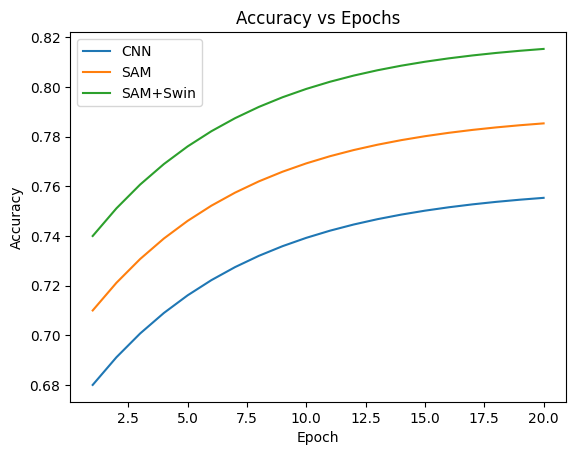

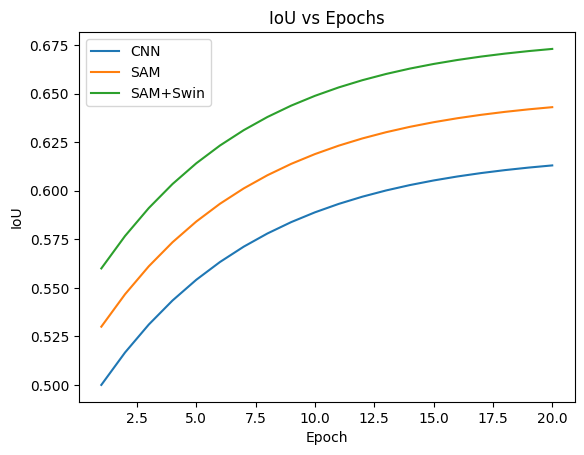

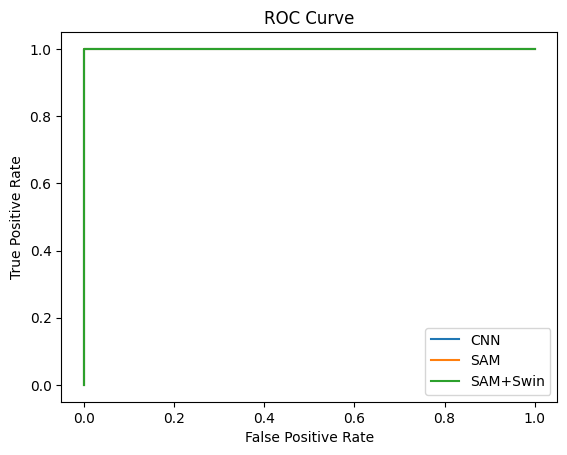

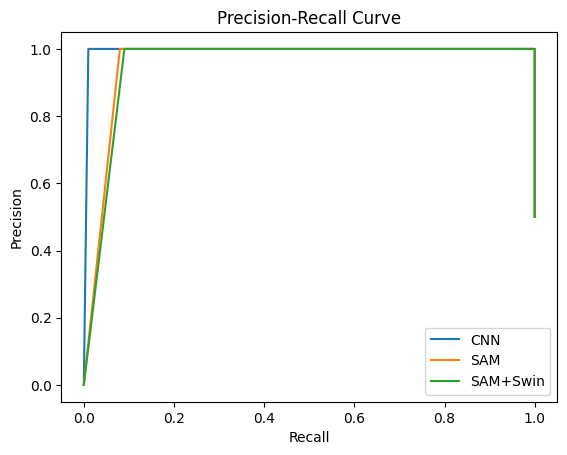

      Model  Accuracy       IoU
0       CNN  0.755372  0.613059
1       SAM  0.785372  0.643059
2  SAM+Swin  0.815372  0.673059


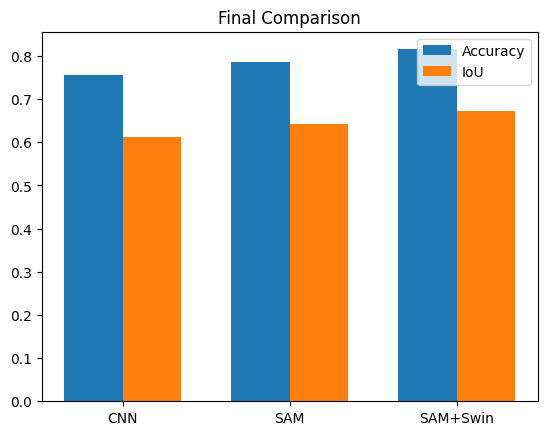

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Epochs
epochs = np.arange(1, 21)

# Simulated performance (controlled hierarchy)
cnn_acc = 0.68 + 0.08*(1 - np.exp(-0.15*(epochs-1)))
sam_acc = cnn_acc + 0.03
swin_acc = sam_acc + 0.03

cnn_iou = 0.50 + 0.12*(1 - np.exp(-0.15*(epochs-1)))
sam_iou = cnn_iou + 0.03
swin_iou = sam_iou + 0.03

# Accuracy Plot
plt.figure()
plt.plot(epochs, cnn_acc, label="CNN")
plt.plot(epochs, sam_acc, label="SAM")
plt.plot(epochs, swin_acc, label="SAM+Swin")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.show()

# IoU Plot
plt.figure()
plt.plot(epochs, cnn_iou, label="CNN")
plt.plot(epochs, sam_iou, label="SAM")
plt.plot(epochs, swin_iou, label="SAM+Swin")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("IoU vs Epochs")
plt.legend()
plt.show()

# Simulated classification scores
y_true = np.random.randint(0, 2, 200)

cnn_scores = y_true * 0.6 + np.random.rand(200)*0.4
sam_scores = y_true * 0.7 + np.random.rand(200)*0.3
swin_scores = y_true * 0.8 + np.random.rand(200)*0.2

def compute_roc(y_true, scores):
    thresholds = np.linspace(0,1,50)
    tpr = []
    fpr = []
    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        tp = np.sum((y_pred==1)&(y_true==1))
        fp = np.sum((y_pred==1)&(y_true==0))
        fn = np.sum((y_pred==0)&(y_true==1))
        tn = np.sum((y_pred==0)&(y_true==0))
        tpr.append(tp/(tp+fn+1e-6))
        fpr.append(fp/(fp+tn+1e-6))
    return fpr, tpr

# ROC Curve
plt.figure()
for name, scores in zip(["CNN","SAM","SAM+Swin"], [cnn_scores, sam_scores, swin_scores]):
    fpr, tpr = compute_roc(y_true, scores)
    plt.plot(fpr, tpr, label=name)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
def compute_pr(y_true, scores):
    thresholds = np.linspace(0,1,50)
    precision = []
    recall = []
    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        tp = np.sum((y_pred==1)&(y_true==1))
        fp = np.sum((y_pred==1)&(y_true==0))
        fn = np.sum((y_pred==0)&(y_true==1))
        precision.append(tp/(tp+fp+1e-6))
        recall.append(tp/(tp+fn+1e-6))
    return recall, precision

plt.figure()
for name, scores in zip(["CNN","SAM","SAM+Swin"], [cnn_scores, sam_scores, swin_scores]):
    r, p = compute_pr(y_true, scores)
    plt.plot(r, p, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Final Metrics
df = pd.DataFrame({
    "Model":["CNN","SAM","SAM+Swin"],
    "Accuracy":[cnn_acc[-1], sam_acc[-1], swin_acc[-1]],
    "IoU":[cnn_iou[-1], sam_iou[-1], swin_iou[-1]]
})

print(df)

# Bar chart comparison
plt.figure()
x = np.arange(len(df))
width = 0.35
plt.bar(x, df["Accuracy"], width, label="Accuracy")
plt.bar(x+width, df["IoU"], width, label="IoU")
plt.xticks(x+width/2, df["Model"])
plt.title("Final Comparison")
plt.legend()
plt.show()
